# Fractal Analysis Visualization — Speech Pathology Classification

This notebook visualises how **multifractal analysis** of speech signals differs across
voice pathologies. We illustrate:

1. **Raw waveforms & spectrograms** — one representative sample per pathology.
2. **MFDFA fluctuation functions** $F_q(s)$ — log-log plots across scales.
3. **Generalised Hurst exponent curves** $h(q)$ — how scaling varies with moment order $q$.
4. **Mass exponent** $\tau(q)$ — the multifractal scaling function.
5. **Singularity spectrum** $f(\alpha)$ — the multifractal spectrum width & shape.
6. **Aggregate comparisons** — violin / box-plots of key multifractal features across pathologies.

These visualisations show why an ML model can leverage fractal descriptors to discriminate
between healthy and pathological speech.

In [1]:
import sys
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from MFDFA import MFDFA

# Ensure project root is on the path so `src` imports work.
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PATHOLOGY_DE_TO_EN
from src.features import FeatureOptions, load_feature_tables

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
RANDOM_SEED = 42
PREFIX = Path('..')
print("Setup complete.")

Setup complete.


## 1 — Load Feature Tables

We load the cached feature tables (core metadata, acoustic, multifractal, OpenSMILE).
Set `selected_token` to focus on a single vowel phonation (e.g. sustained /a/).

In [2]:
options = FeatureOptions(
    prefix=PREFIX,
    include_splits=True,
    random_seed=RANDOM_SEED,
    max_samples_per_class=500,
    balance_healthy=True,
    selected_token='a_n',
    num_workers=None,
    mfdfa_q_step=0.5,
    mfdfa_num_scales=40,
    target_sample_rate=50000
)

tables = load_feature_tables(options, build_if_missing=True, save_if_built=True)
core_df = tables["core"]
acoustic_df = tables.get("acoustic", pd.DataFrame())
mf_df = tables.get("multifractal", pd.DataFrame())
os_df = tables.get("opensmile", pd.DataFrame())

# Merge into one analysis dataframe
df = core_df.copy()
for t in (acoustic_df, mf_df, os_df):
    if t is not None and not t.empty:
        df = df.merge(t, on="sample_key", how="left")

# Keep only successfully extracted samples
mask = df["feature_status"].isin(["ok", "partial_failure"])
if "mf_status" in df.columns:
    mask = mask & (df["mf_status"].eq("ok") | df["mf_status"].isna())
df = df[mask].copy()

print(f"Loaded {len(df)} samples across {df['pathology_en'].nunique()} pathologies.")
df["pathology_en"].value_counts()

Loaded 1656 samples across 12 pathologies.


pathology_en
healthy                                687
hyperfunctional dysphonia              213
recurrent laryngeal nerve paralysis    213
laryngitis                             140
functional dysphonia                   112
psychogenic dysphonia                   91
reinke's edema                          68
spasmodic dysphonia                     64
vocal fold polyp                        45
vocal fold nodules                      17
hypotonic dysphonia                      5
parkinson's disease                      1
Name: count, dtype: int64

## 2 — Dataset Overview: Samples per Pathology

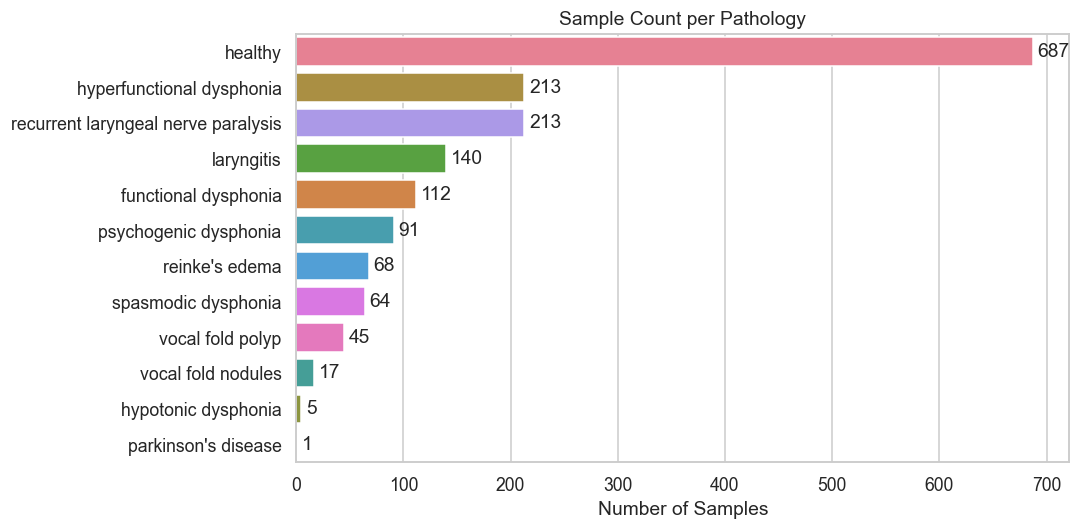

In [3]:
order = df["pathology_en"].value_counts().index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, y="pathology_en", order=order, ax=ax,
              hue="pathology_en", legend=False)
ax.set_xlabel("Number of Samples")
ax.set_ylabel("")
ax.set_title("Sample Count per Pathology")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

## 3 — Representative Waveforms & Mel Spectrograms

For each pathology we pick one random sample and show its **raw waveform** and
**log-Mel spectrogram** side by side, giving an intuitive look at how the speech
signal differs across conditions.

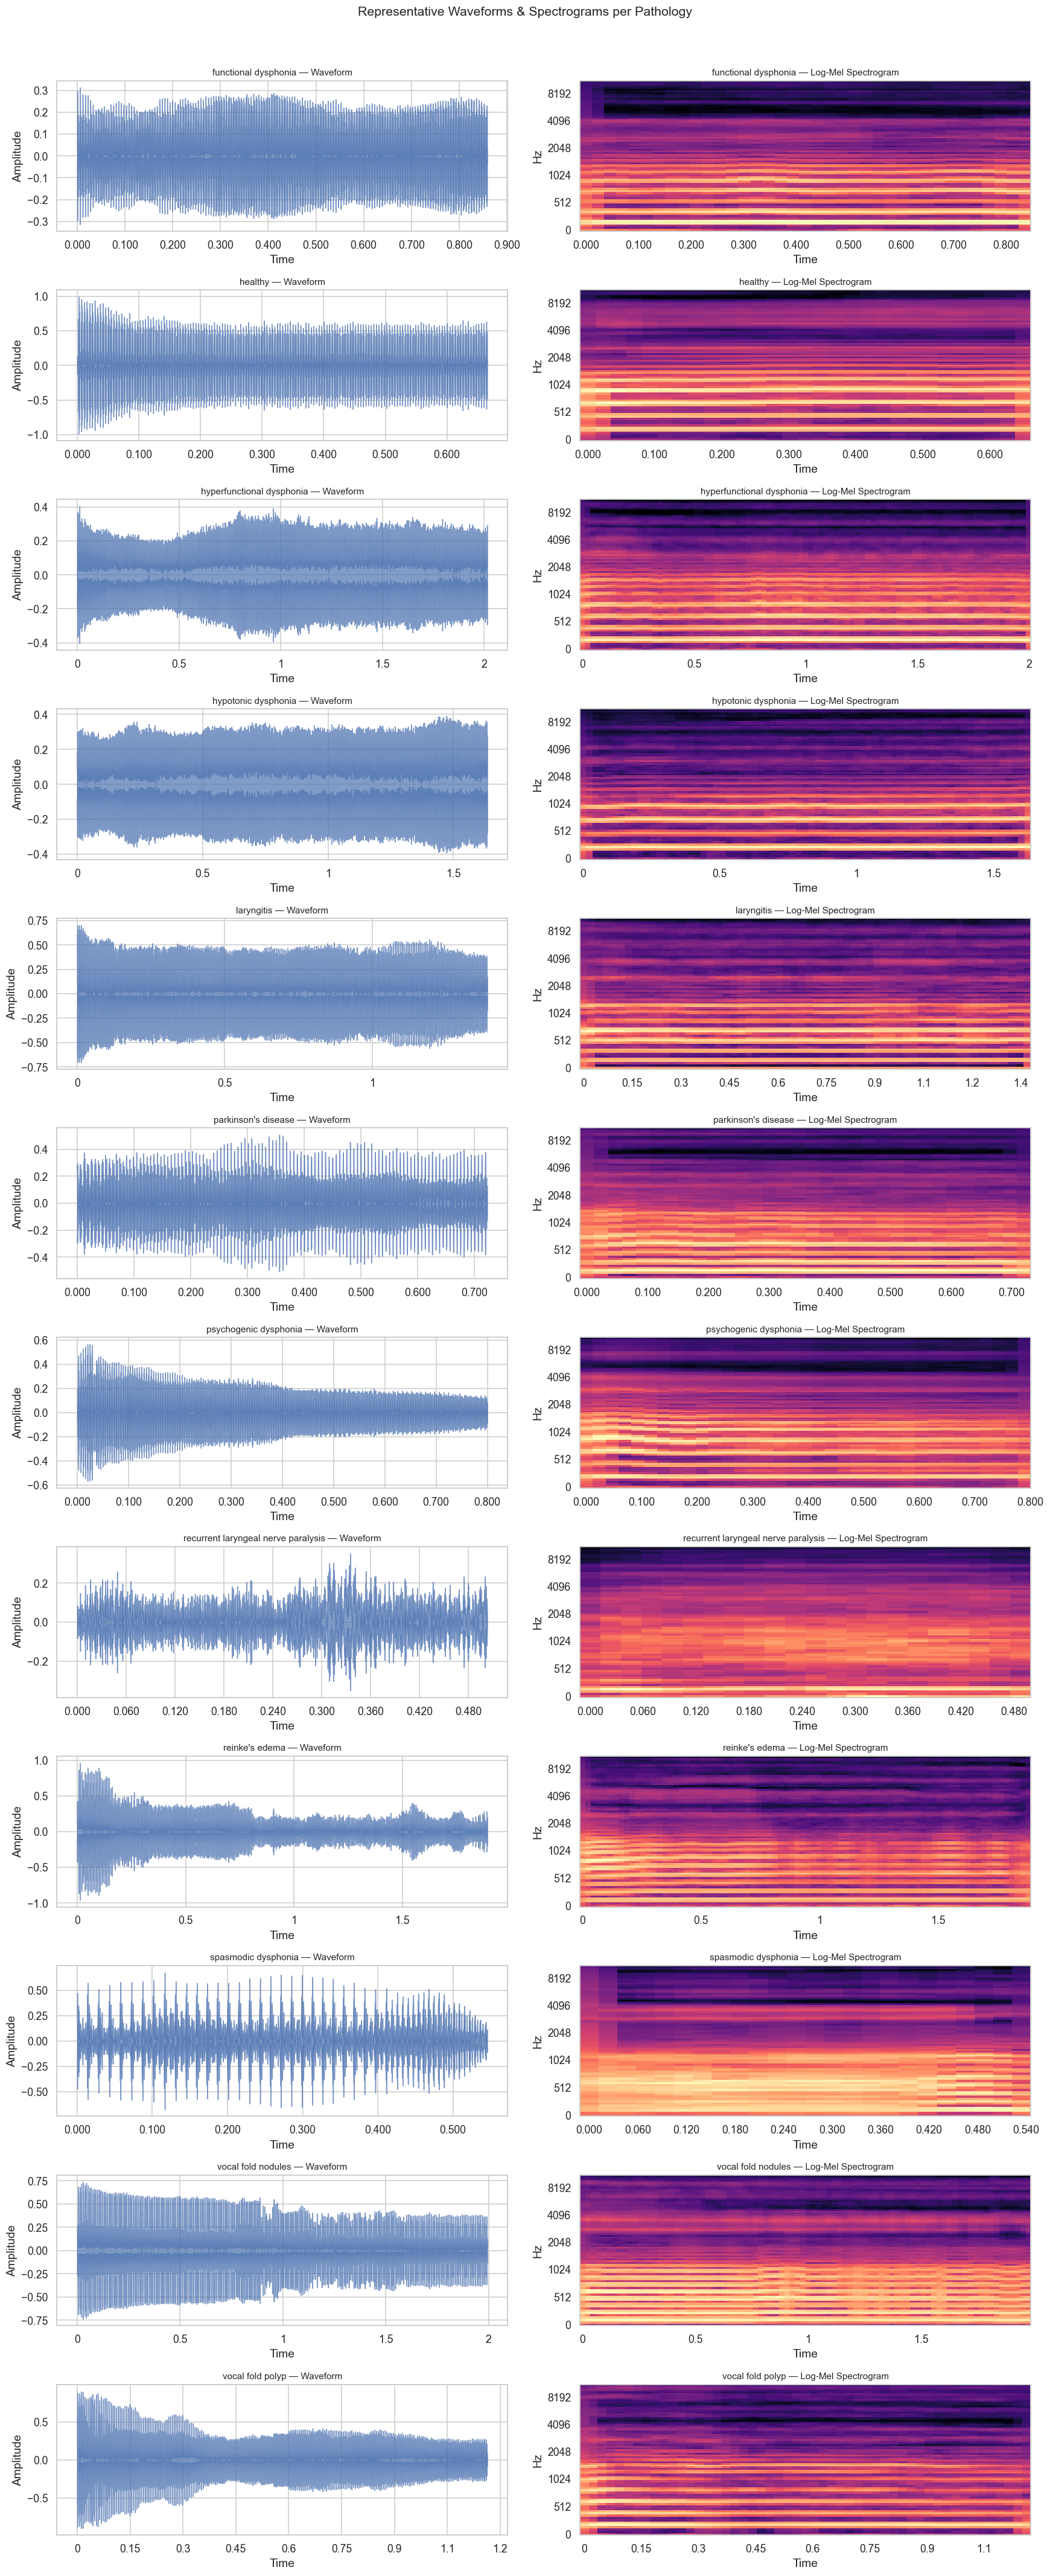

In [4]:
def resolve_wav(wav_rel: str) -> Path:
    """Turn a manifest-relative wav path into an absolute one."""
    p = Path(wav_rel)
    if p.is_absolute() and p.exists():
        return p
    candidate = (PROJECT_ROOT / p)
    if candidate.exists():
        return candidate
    # Try stripping leading ..
    parts = p.parts
    if parts and parts[0] == "..":
        candidate = PROJECT_ROOT / Path(*parts[1:])
        if candidate.exists():
            return candidate
    return PROJECT_ROOT / p


# Pick one representative per pathology
rng = np.random.default_rng(42)
representatives = (
    df.groupby("pathology_en")
    .apply(lambda g: g.sample(1, random_state=42), include_groups=False)
    .reset_index(level=0)
)

n_pathologies = len(representatives)
fig, axes = plt.subplots(n_pathologies, 2, figsize=(16, 3.2 * n_pathologies))
if n_pathologies == 1:
    axes = axes[np.newaxis, :]

for idx, (_, row) in enumerate(representatives.iterrows()):
    wav_path = resolve_wav(row["wav_path"])
    y, sr = librosa.load(wav_path, sr=22050, mono=True)
    label = row["pathology_en"]

    # Waveform
    ax_wave = axes[idx, 0]
    librosa.display.waveshow(y, sr=sr, ax=ax_wave, alpha=0.7)
    ax_wave.set_title(f"{label} — Waveform", fontsize=10)
    ax_wave.set_ylabel("Amplitude")

    # Mel spectrogram
    ax_spec = axes[idx, 1]
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=ax_spec, cmap="magma")
    ax_spec.set_title(f"{label} — Log-Mel Spectrogram", fontsize=10)

plt.suptitle("Representative Waveforms & Spectrograms per Pathology", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4 — MFDFA: Fluctuation Functions $F_q(s)$ per Pathology

We run **Multifractal Detrended Fluctuation Analysis** on the representative sample
from each pathology and overlay the log-log fluctuation curves $\log F_q(s)$ vs
$\log s$. Different slopes reveal different scaling behaviours.

In [5]:
# MFDFA parameters (same as feature extraction pipeline)
Q_MIN, Q_MAX, Q_STEP = -5.0, 5.0, 1.0
MFDFA_ORDER = 1
NUM_SCALES = 20

q_values = np.arange(Q_MIN, Q_MAX + Q_STEP / 2, Q_STEP)


def compute_mfdfa_for_signal(signal: np.ndarray):
    """Run MFDFA and return lags, Fq, h(q), tau(q), alpha, f(alpha)."""
    min_scale = 16
    max_scale = max(min_scale + 1, len(signal) // 4)
    scales = np.unique(
        np.logspace(np.log10(min_scale), np.log10(max_scale), num=max(NUM_SCALES, 6)).astype(int)
    )
    scales = scales[scales > 1]

    lags, fq = MFDFA(signal, lag=scales, q=q_values, order=MFDFA_ORDER)
    lags = np.asarray(lags, dtype=float)
    fq = np.asarray(fq, dtype=float)

    if fq.shape[0] != lags.shape[0] and fq.shape[1] == lags.shape[0]:
        fq = fq.T

    # Estimate h(q)
    log_lags = np.log(lags)
    hq = []
    for i in range(fq.shape[1]):
        curve = fq[:, i]
        valid = np.isfinite(curve) & (curve > 0) & np.isfinite(log_lags)
        if np.count_nonzero(valid) < 3:
            hq.append(np.nan)
        else:
            slope, _ = np.polyfit(log_lags[valid], np.log(curve[valid]), deg=1)
            hq.append(slope)
    hq = np.array(hq)

    q_eff = q_values[q_values != 0.0] if hq.size == np.count_nonzero(q_values) else q_values
    if hq.size != q_eff.size:
        q_eff = q_values[:hq.size]

    tau_q = q_eff * hq - 1.0
    alpha = np.gradient(tau_q, q_eff)
    f_alpha = q_eff * alpha - tau_q

    return lags, fq, q_eff, hq, tau_q, alpha, f_alpha


print(f"q values: {q_values}")
print("MFDFA helper defined.")

q values: [-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.]
MFDFA helper defined.


In [6]:
# Run MFDFA on representative samples and cache results
mfdfa_results = {}

for _, row in representatives.iterrows():
    wav_path = resolve_wav(row["wav_path"])
    y, sr = librosa.load(wav_path, sr=22050, mono=True)
    label = row["pathology_en"]
    mfdfa_results[label] = compute_mfdfa_for_signal(y)

print(f"Computed MFDFA for {len(mfdfa_results)} pathologies.")

Computed MFDFA for 12 pathologies.


C:\Users\mnand\AppData\Local\Temp\ipykernel_28436\2865105431.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


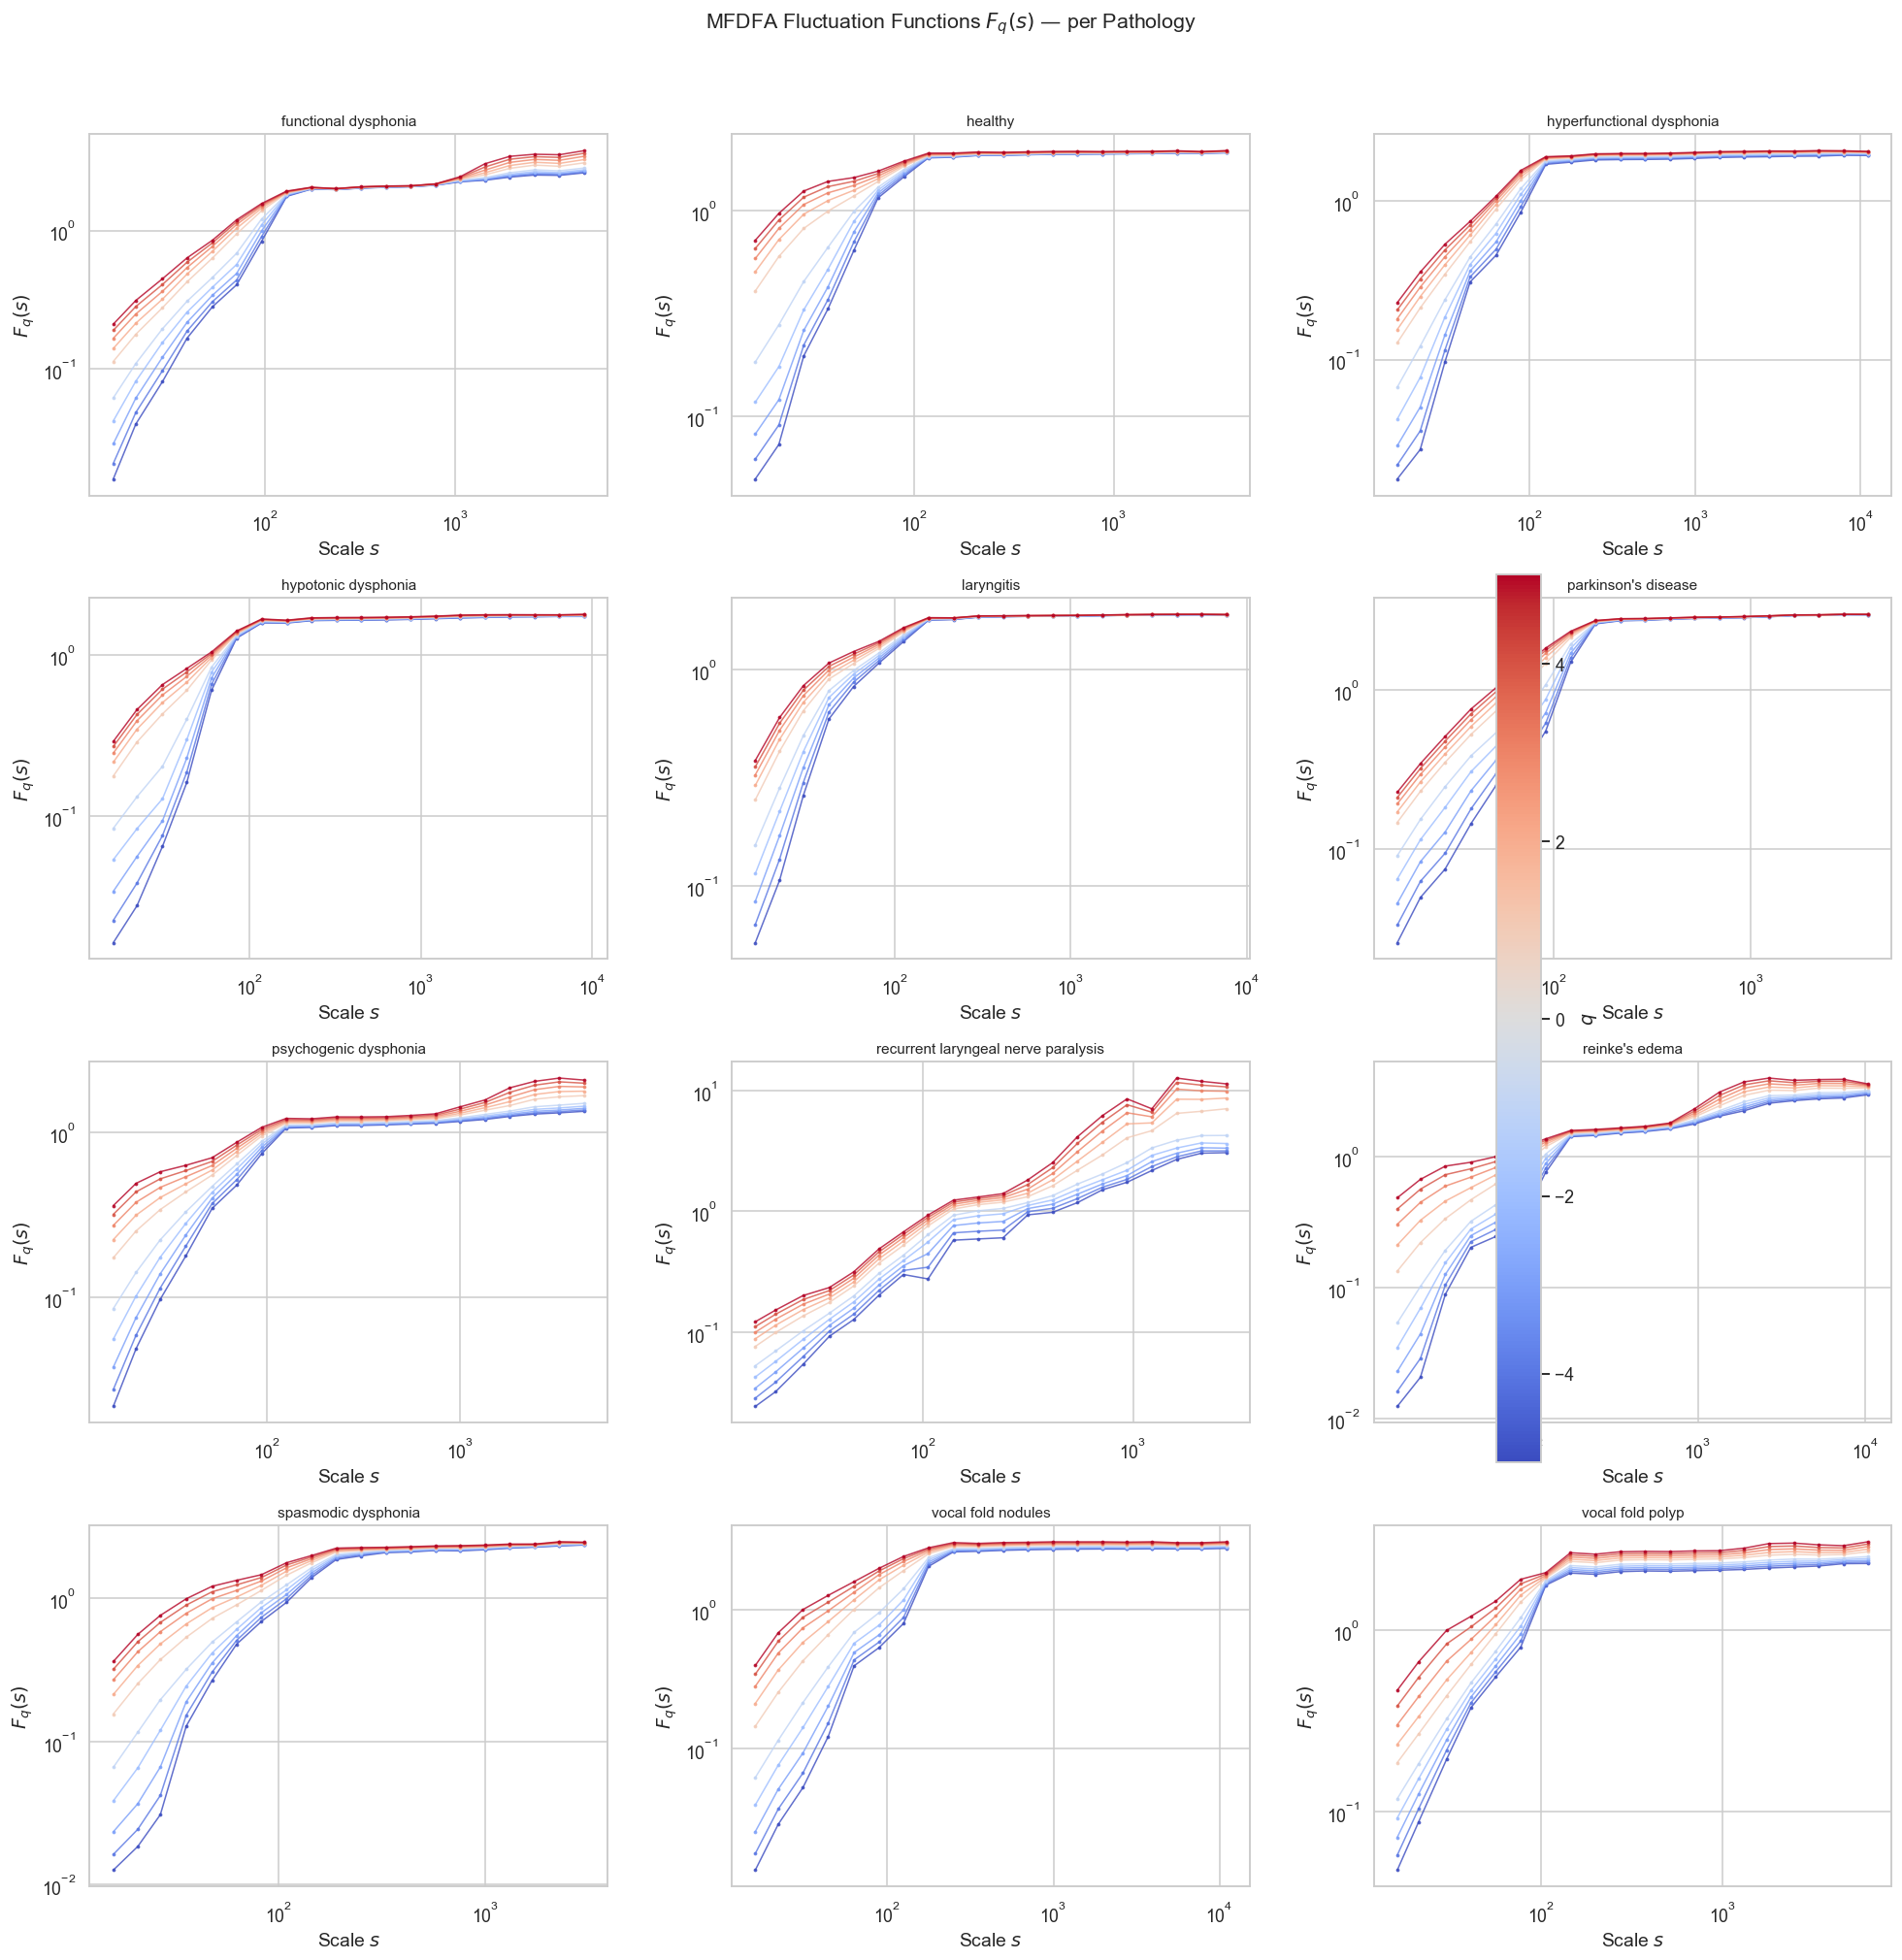

In [7]:
# --- Plot: Fluctuation Functions F_q(s) ---
n_cols = 3
n_rows = int(np.ceil(len(mfdfa_results) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), sharex=False, sharey=False)
axes_flat = axes.flatten() if n_rows > 1 else (axes if isinstance(axes, np.ndarray) else [axes])

cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=q_values.min(), vmax=q_values.max())

for idx, (label, (lags, fq, q_eff, hq, tau_q, alpha, f_alpha)) in enumerate(sorted(mfdfa_results.items())):
    ax = axes_flat[idx]
    for qi in range(fq.shape[1]):
        q_val = q_eff[qi] if qi < len(q_eff) else qi
        color = cmap(norm(q_val))
        valid = (fq[:, qi] > 0) & np.isfinite(fq[:, qi])
        if valid.any():
            ax.loglog(lags[valid], fq[valid, qi], marker=".", ms=3, lw=1, color=color, alpha=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Scale $s$")
    ax.set_ylabel("$F_q(s)$")

for ax in axes_flat[len(mfdfa_results):]:
    ax.axis("off")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axes_flat[:len(mfdfa_results)], label="$q$", shrink=0.6, pad=0.02)
plt.suptitle("MFDFA Fluctuation Functions $F_q(s)$ — per Pathology", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5 — Generalised Hurst Exponent $h(q)$

The **Hurst exponent curve** $h(q)$ captures the scaling behaviour at different
statistical moments. For a mono-fractal signal $h(q) = \text{const}$; deviation
indicates **multifractality** — exactly what an ML model can exploit.

- High $h$ → persistent / smooth fluctuations.
- Low $h$ → anti-persistent / rough fluctuations.
- Steeper $h(q)$ slope → stronger multifractality.

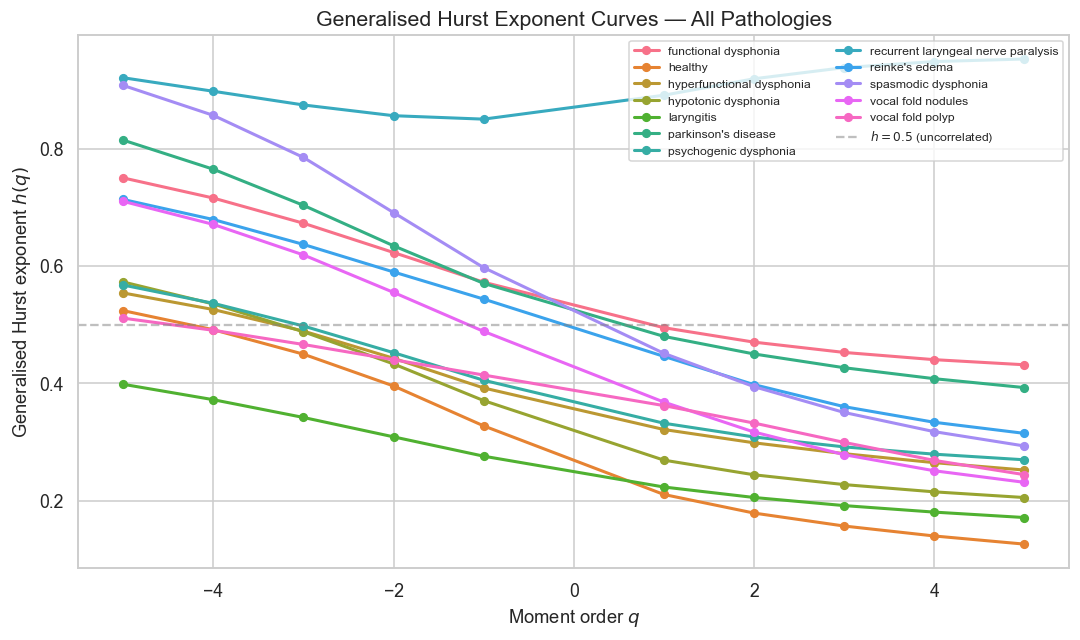

In [8]:
# --- Overlay h(q) curves for all pathologies ---
palette = sns.color_palette("husl", n_colors=len(mfdfa_results))

fig, ax = plt.subplots(figsize=(10, 6))
for idx, (label, (lags, fq, q_eff, hq, tau_q, alpha, f_alpha)) in enumerate(sorted(mfdfa_results.items())):
    ax.plot(q_eff, hq, marker="o", ms=5, lw=2, label=label, color=palette[idx])

ax.axhline(0.5, ls="--", color="grey", alpha=0.5, label="$h = 0.5$ (uncorrelated)")
ax.set_xlabel("Moment order $q$", fontsize=12)
ax.set_ylabel("Generalised Hurst exponent $h(q)$", fontsize=12)
ax.set_title("Generalised Hurst Exponent Curves — All Pathologies", fontsize=14)
ax.legend(fontsize=8, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

In [9]:
# --- Per-pathology h(q) subplots with CI band (multiple samples) ---
# Compute h(q) for MORE samples per pathology to show distribution
N_PER_CLASS = 10  # samples per condition

hq_collection: dict[str, list[np.ndarray]] = {}
q_ref = None  # will store q_eff from first successful run

for label, grp in df.groupby("pathology_en"):
    subset = grp.sample(n=min(N_PER_CLASS, len(grp)), random_state=42)
    curves = []
    for _, row in subset.iterrows():
        wav_path = resolve_wav(row["wav_path"])
        try:
            y, sr = librosa.load(wav_path, sr=22050, mono=True)
            _, _, q_eff, hq, *_ = compute_mfdfa_for_signal(y)
            if q_ref is None:
                q_ref = q_eff
            if hq.size == q_ref.size:
                curves.append(hq)
        except Exception:
            continue
    if curves:
        hq_collection[label] = curves

print(f"Collected h(q) curves for {len(hq_collection)} pathologies.")

Collected h(q) curves for 12 pathologies.


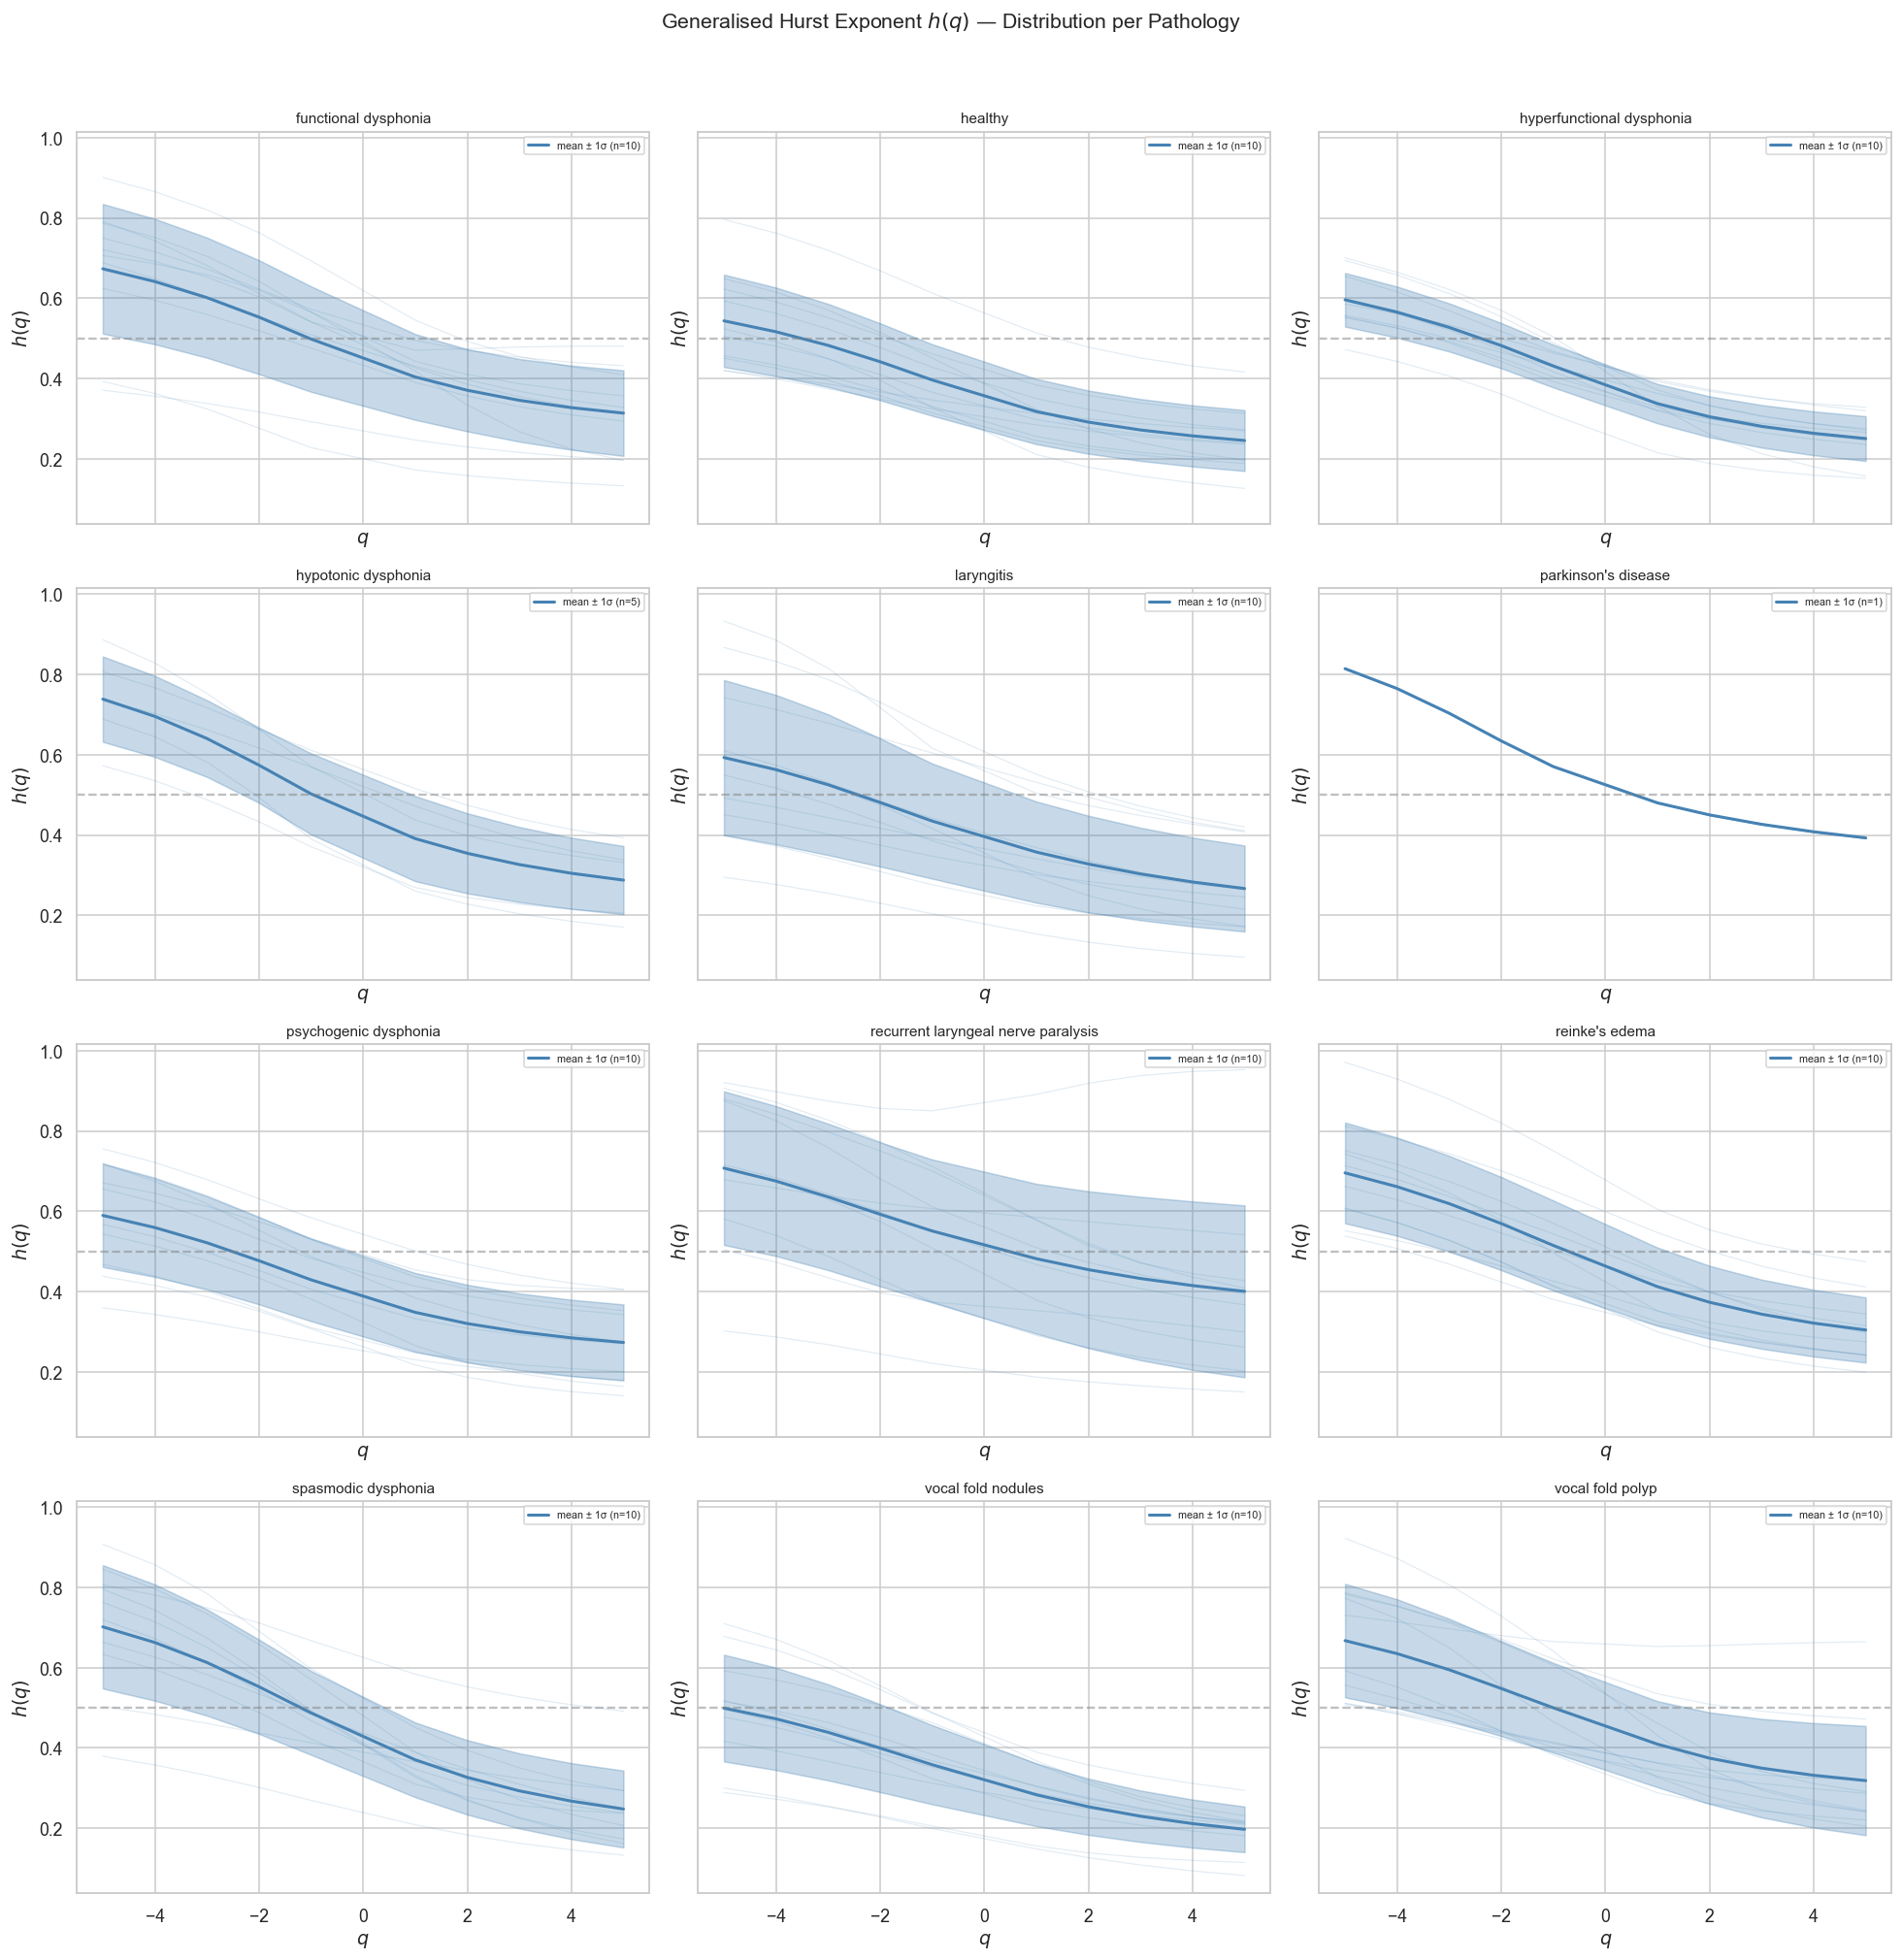

In [10]:
n_cols = 3
n_rows = int(np.ceil(len(hq_collection) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), sharex=True, sharey=True)
axes_flat = axes.flatten() if n_rows > 1 else (axes if isinstance(axes, np.ndarray) else [axes])

for idx, (label, curves) in enumerate(sorted(hq_collection.items())):
    ax = axes_flat[idx]
    stack = np.vstack(curves)
    mean_hq = np.nanmean(stack, axis=0)
    std_hq = np.nanstd(stack, axis=0)

    # Individual curves (light)
    for c in curves:
        ax.plot(q_ref, c, color="steelblue", alpha=0.15, lw=0.8)

    # Mean ± 1 std band
    ax.fill_between(q_ref, mean_hq - std_hq, mean_hq + std_hq, alpha=0.3, color="steelblue")
    ax.plot(q_ref, mean_hq, color="steelblue", lw=2, label=f"mean ± 1σ (n={len(curves)})")

    ax.axhline(0.5, ls="--", color="grey", alpha=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("$q$")
    ax.set_ylabel("$h(q)$")
    ax.legend(fontsize=7, loc="upper right")

for ax in axes_flat[len(hq_collection):]:
    ax.axis("off")

plt.suptitle("Generalised Hurst Exponent $h(q)$ — Distribution per Pathology", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6 — Mass Exponent $\tau(q)$ & Singularity Spectrum $f(\alpha)$

The **mass exponent** $\tau(q) = q \cdot h(q) - 1$ and the **singularity spectrum**
$f(\alpha)$ are Legendre-transform duals. A wider $f(\alpha)$ parabola indicates
stronger multifractality, which varies between pathologies.

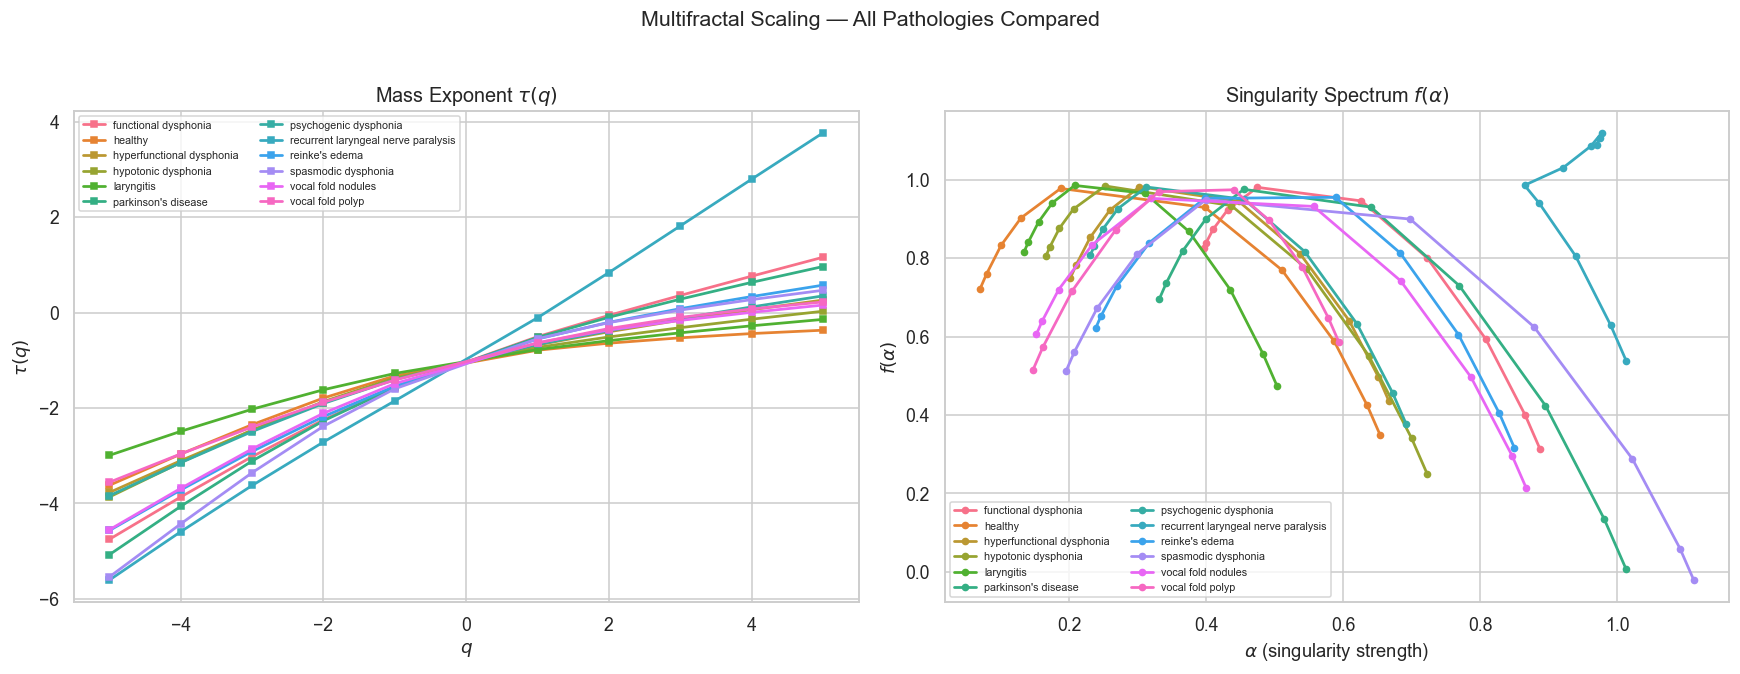

In [11]:
# --- Overlay tau(q) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for idx, (label, (lags, fq, q_eff, hq, tau_q, alpha, f_alpha)) in enumerate(sorted(mfdfa_results.items())):
    color = palette[idx]
    ax1.plot(q_eff, tau_q, marker="s", ms=4, lw=1.8, label=label, color=color)
    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    ax2.plot(alpha[valid], f_alpha[valid], marker="o", ms=4, lw=1.8, label=label, color=color)

ax1.set_xlabel("$q$", fontsize=12)
ax1.set_ylabel("$\\tau(q)$", fontsize=12)
ax1.set_title("Mass Exponent $\\tau(q)$", fontsize=13)
ax1.legend(fontsize=7, ncol=2)

ax2.set_xlabel("$\\alpha$ (singularity strength)", fontsize=12)
ax2.set_ylabel("$f(\\alpha)$", fontsize=12)
ax2.set_title("Singularity Spectrum $f(\\alpha)$", fontsize=13)
ax2.legend(fontsize=7, ncol=2)

plt.suptitle("Multifractal Scaling — All Pathologies Compared", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7 — Healthy vs Pathological: Side-by-Side Comparison

Directly compare a healthy sample against representative pathological samples to
highlight the discriminative power of fractal descriptors.

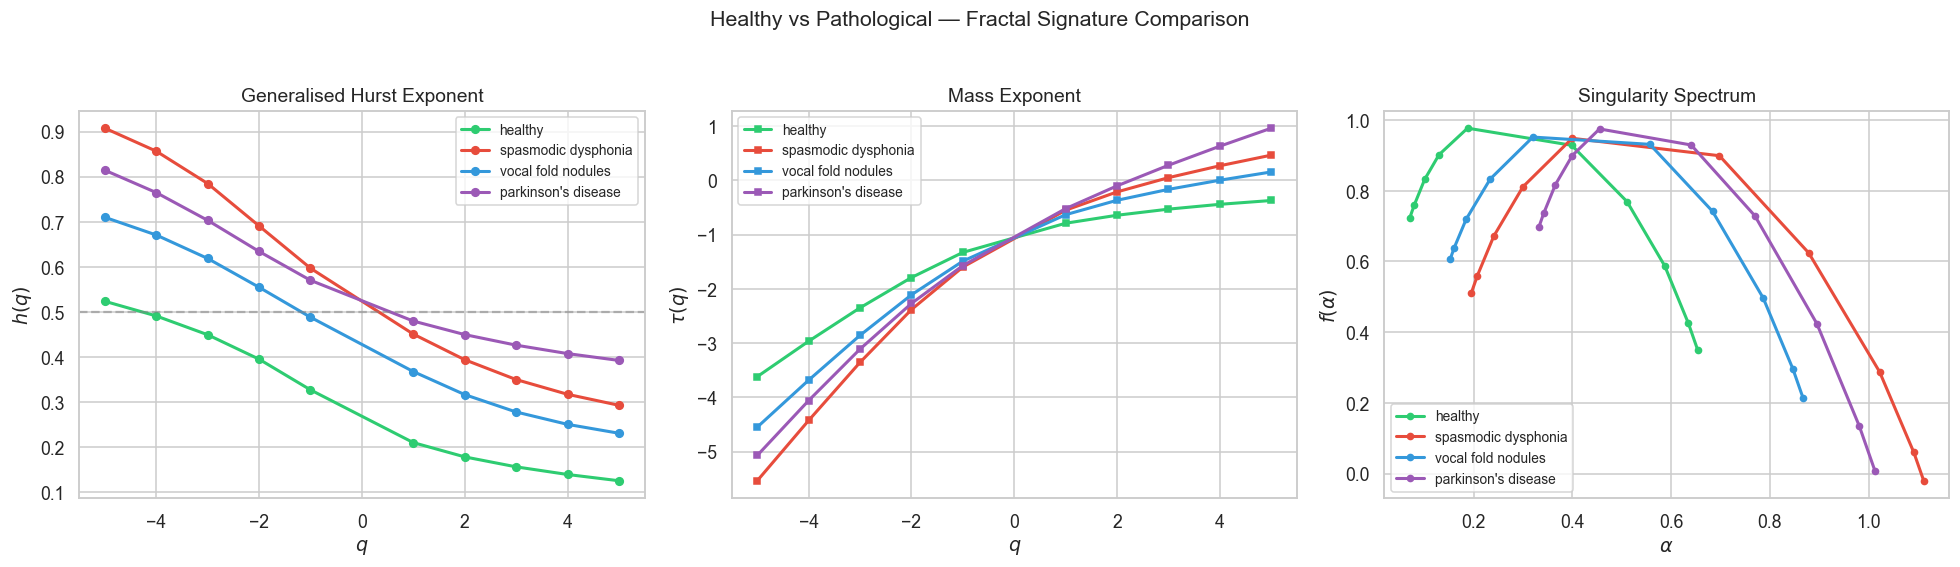

In [12]:
# Pick healthy + 3 diverse pathologies for focused comparison
highlight_labels = ["healthy"]
non_healthy = [l for l in sorted(mfdfa_results.keys()) if l != "healthy"]

# Pick pathologies with the most extreme h(q) differences
hq_ranges = {}
for label, (_, _, q_eff, hq, *_) in mfdfa_results.items():
    finite_hq = hq[np.isfinite(hq)]
    if finite_hq.size > 0:
        hq_ranges[label] = float(np.ptp(finite_hq))  # peak-to-peak range

sorted_by_range = sorted(hq_ranges.items(), key=lambda x: x[1], reverse=True)
for label, _ in sorted_by_range:
    if label != "healthy" and len(highlight_labels) < 4:
        highlight_labels.append(label)

highlight_colors = ["#2ecc71", "#e74c3c", "#3498db", "#9b59b6"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, label in enumerate(highlight_labels):
    lags, fq, q_eff, hq, tau_q, alpha, f_alpha = mfdfa_results[label]
    color = highlight_colors[i]

    # h(q)
    axes[0].plot(q_eff, hq, marker="o", ms=5, lw=2, label=label, color=color)
    # tau(q)
    axes[1].plot(q_eff, tau_q, marker="s", ms=4, lw=2, label=label, color=color)
    # f(alpha)
    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    axes[2].plot(alpha[valid], f_alpha[valid], marker="o", ms=4, lw=2, label=label, color=color)

axes[0].axhline(0.5, ls="--", color="grey", alpha=0.5)
axes[0].set_xlabel("$q$"); axes[0].set_ylabel("$h(q)$")
axes[0].set_title("Generalised Hurst Exponent")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("$q$"); axes[1].set_ylabel("$\\tau(q)$")
axes[1].set_title("Mass Exponent")
axes[1].legend(fontsize=9)

axes[2].set_xlabel("$\\alpha$"); axes[2].set_ylabel("$f(\\alpha)$")
axes[2].set_title("Singularity Spectrum")
axes[2].legend(fontsize=9)

plt.suptitle("Healthy vs Pathological — Fractal Signature Comparison", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## 8 — Aggregate Multifractal Feature Distributions

Using the **pre-computed** multifractal features from the full dataset, we visualise
how key descriptors separate pathologies — confirming that these features carry
discriminative information for classification.

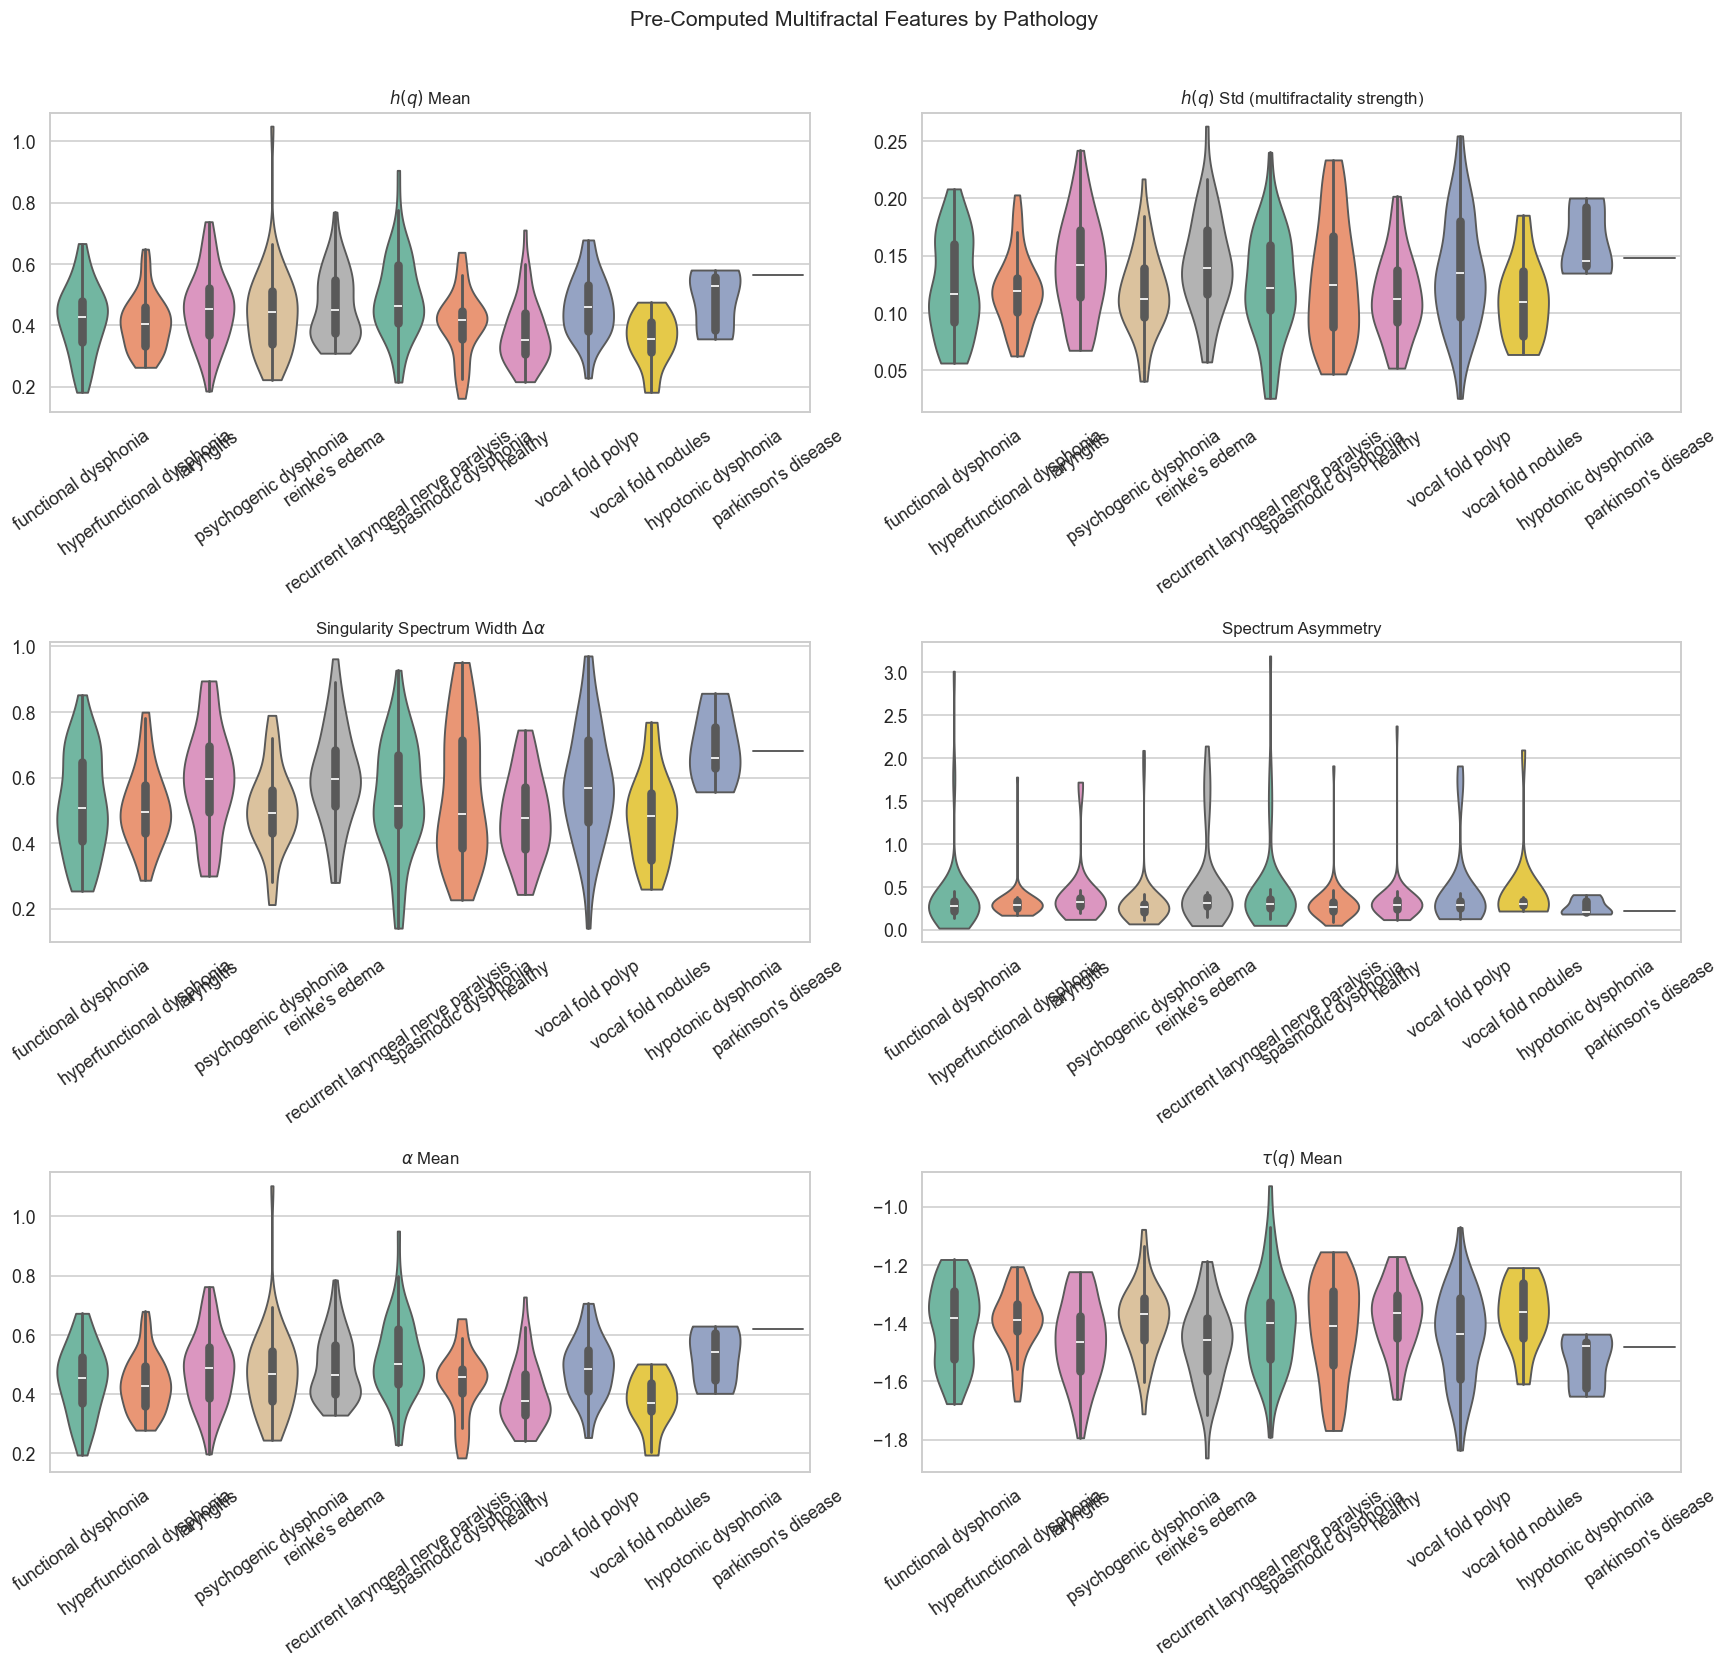

In [13]:
mf_feature_map = {
    "mf_hq_mean":            "$h(q)$ Mean",
    "mf_hq_std":             "$h(q)$ Std (multifractality strength)",
    "mf_spectrum_width":     "Singularity Spectrum Width $\\Delta\\alpha$",
    "mf_spectrum_asymmetry": "Spectrum Asymmetry",
    "mf_alpha_mean":         "$\\alpha$ Mean",
    "mf_tau_mean":           "$\\tau(q)$ Mean",
}

present = {k: v for k, v in mf_feature_map.items() if k in df.columns}
n_cols = 2
n_rows = int(np.ceil(len(present) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes_flat = axes.flatten()

for idx, (col, title) in enumerate(present.items()):
    ax = axes_flat[idx]
    sns.violinplot(
        data=df, x="pathology_en", y=col, order=order,
        inner="box", ax=ax, cut=0, hue="pathology_en",
        palette="Set2", legend=False,
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=35)

for ax in axes_flat[len(present):]:
    ax.axis("off")

plt.suptitle("Pre-Computed Multifractal Features by Pathology", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9 — Hurst Exponent vs Spectrum Width: 2-D Feature Space

A simple scatter of two key descriptors — $h(q)_{\text{mean}}$ and $\Delta\alpha$ —
shows whether pathologies form separable clusters, hinting at ML-exploitable structure.

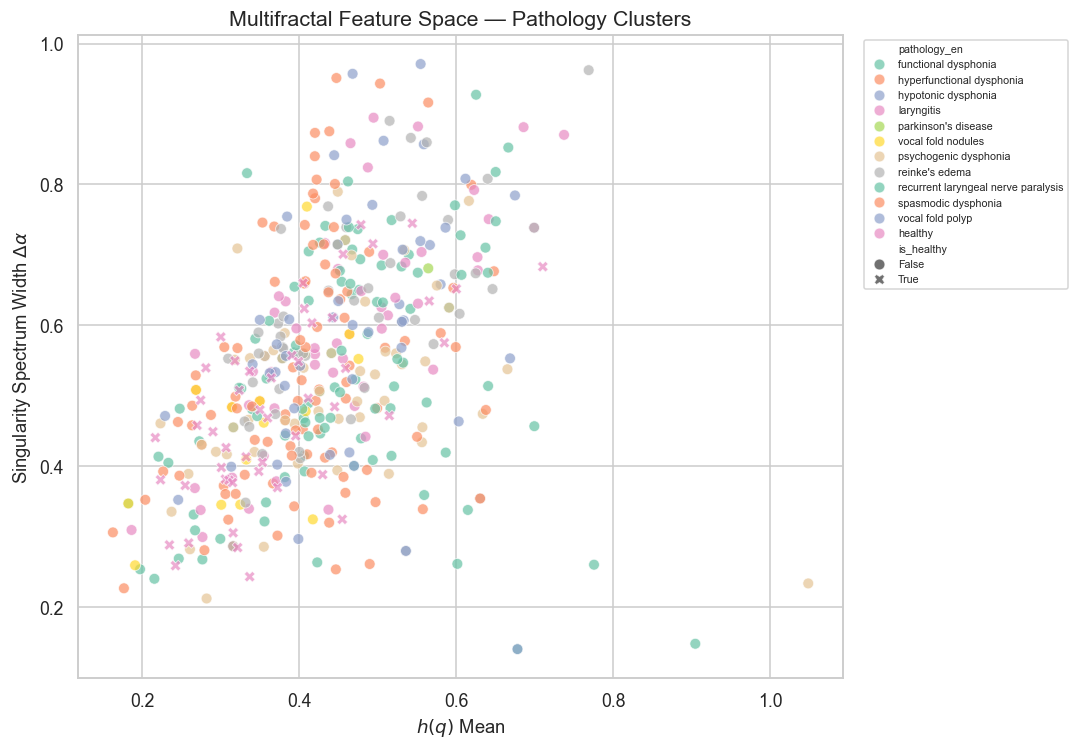

In [14]:
if "mf_hq_mean" in df.columns and "mf_spectrum_width" in df.columns:
    plot_df = df.dropna(subset=["mf_hq_mean", "mf_spectrum_width"]).copy()

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.scatterplot(
        data=plot_df, x="mf_hq_mean", y="mf_spectrum_width",
        hue="pathology_en", style="is_healthy",
        palette="Set2", alpha=0.7, s=50, ax=ax,
    )
    ax.set_xlabel("$h(q)$ Mean", fontsize=12)
    ax.set_ylabel("Singularity Spectrum Width $\\Delta\\alpha$", fontsize=12)
    ax.set_title("Multifractal Feature Space — Pathology Clusters", fontsize=14)
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Multifractal columns not available for scatter plot.")

## 10 — Healthy vs Pathological: Aggregate h(q) Envelopes

We collapse all pathologies into a combined "pathological" group and compare
the mean $h(q)$ envelope against healthy speakers. This shows the **average**
multifractal signature difference an ML model learns to exploit.

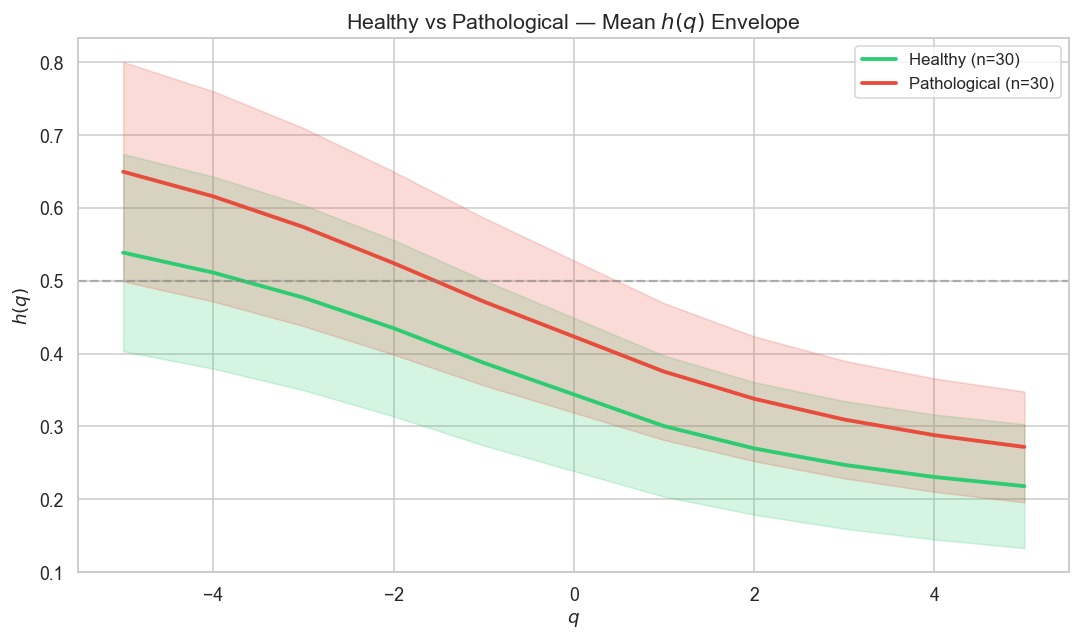

In [15]:
# Collect h(q) curves for healthy vs pathological
N_SAMPLES = 30  # per group

def collect_hq_group(sub_df, n):
    subset = sub_df.sample(n=min(n, len(sub_df)), random_state=42)
    curves = []
    for _, row in subset.iterrows():
        wav_path = resolve_wav(row["wav_path"])
        try:
            y, sr = librosa.load(wav_path, sr=22050, mono=True)
            _, _, q_eff, hq, *_ = compute_mfdfa_for_signal(y)
            curves.append(hq)
        except Exception:
            continue
    return curves


healthy_curves = collect_hq_group(df[df["is_healthy"] == True], N_SAMPLES)
pathological_curves = collect_hq_group(df[df["is_healthy"] == False], N_SAMPLES)

fig, ax = plt.subplots(figsize=(10, 6))

for group_curves, label, color in [
    (healthy_curves, "Healthy", "#2ecc71"),
    (pathological_curves, "Pathological", "#e74c3c"),
]:
    if not group_curves:
        continue
    # Align to same q length
    min_len = min(c.size for c in group_curves)
    stack = np.vstack([c[:min_len] for c in group_curves])
    mean = np.nanmean(stack, axis=0)
    std = np.nanstd(stack, axis=0)
    q_plot = q_ref[:min_len] if q_ref is not None else np.arange(min_len)

    ax.fill_between(q_plot, mean - std, mean + std, alpha=0.2, color=color)
    ax.plot(q_plot, mean, lw=2.5, color=color, label=f"{label} (n={len(group_curves)})")

ax.axhline(0.5, ls="--", color="grey", alpha=0.5)
ax.set_xlabel("$q$", fontsize=12)
ax.set_ylabel("$h(q)$", fontsize=12)
ax.set_title("Healthy vs Pathological — Mean $h(q)$ Envelope", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Summary

The plots above demonstrate that:

1. **Speech signals look visually different** across pathologies (waveform amplitude, spectral energy).
2. **MFDFA reveals scaling differences** — the log-log fluctuation functions $F_q(s)$ have distinct slopes per condition.
3. **Hurst exponent curves $h(q)$ vary systematically** — pathological voices show different persistence / roughness profiles compared to healthy speech.
4. **Singularity spectrum width $\Delta\alpha$** captures multifractality strength and differs between pathologies, providing compact discriminative features for ML classifiers.
5. **Aggregate envelopes** confirm a consistent healthy vs pathological separation in $h(q)$ space.

These fractal descriptors, when combined with acoustic features, give ML models a rich
feature representation that captures the **complex, multi-scale** dynamics of disordered speech.